In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.1 MB/s eta 0:00:00


[I 2026-04-09 09:15:28,653] A new study created in memory with name: no-name-5e0fff43-27f4-4746-b612-55feb5772f0a


Starting Optuna Optimization...


[I 2026-04-09 09:16:10,027] Trial 0 finished with value: 0.9015583451443021 and parameters: {'rf_n_estimators': 171, 'rf_max_depth': 8, 'xgb_lr': 0.015033839885670293, 'xgb_n_estimators': 228, 'xgb_max_depth': 5, 'meta_c': 0.9758895035521901}. Best is trial 0 with value: 0.9015583451443021.
[I 2026-04-09 09:17:03,622] Trial 1 finished with value: 0.8986853683483726 and parameters: {'rf_n_estimators': 137, 'rf_max_depth': 10, 'xgb_lr': 0.013842217024590901, 'xgb_n_estimators': 219, 'xgb_max_depth': 6, 'meta_c': 0.6384012343225989}. Best is trial 0 with value: 0.9015583451443021.
[I 2026-04-09 09:17:44,707] Trial 2 finished with value: 0.9016672111981935 and parameters: {'rf_n_estimators': 135, 'rf_max_depth': 4, 'xgb_lr': 0.014235282863262064, 'xgb_n_estimators': 335, 'xgb_max_depth': 5, 'meta_c': 0.43618494399162044}. Best is trial 2 with value: 0.9016672111981935.
[I 2026-04-09 09:18:15,181] Trial 3 finished with value: 0.8981118789578632 and parameters: {'rf_n_estimators': 134, 'rf_m


Optimization Finished. Best ROC-AUC: 0.9067
Refitting final model on the 100% full training set...
Final model is now trained on 100% of the data!

Generating SHAP Global Summary...


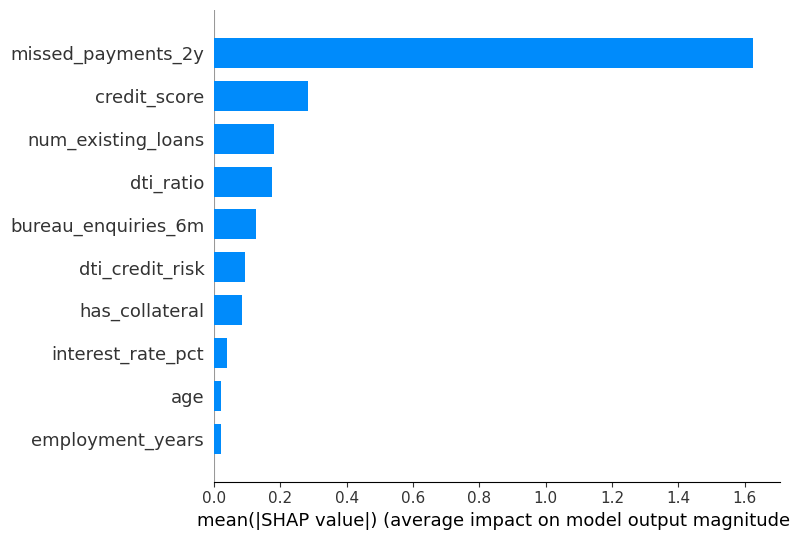


TASK 5: BUSINESS SUMMARY FOR CREDIT COMMITTEE
MODEL PERFORMANCE: Final AUC-ROC achieved: 0.9067


In [3]:
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from xgboost import XGBClassifier

# ==========================================
# 1. DATA PREPROCESSING (TASK 2 COMPLIANT)
# ==========================================
def prepare_data(filepath):
    df = pd.read_csv(filepath)

    # Task 2.3: LTV Sentinel Value & Binary Flag
    df['is_home_loan'] = df['ltv_ratio'].notnull().astype(int)
    df['ltv_ratio'] = df['ltv_ratio'].fillna(-1)

    # Outlier treatment
    cap_val = df['missed_payments_2y'].quantile(0.99)
    df['missed_payments_2y'] = df['missed_payments_2y'].clip(upper=cap_val)

    # Task 2.1: REQUIRED Engineered Features
    # loan_to_income_ratio = loan_amount_inr / annual_income_inr
    df['loan_to_income_ratio'] = df['loan_amount_inr'] / (df['annual_income_inr'] + 1)

    # dti_credit_risk = dti_ratio / (credit_score / 700)
    df['dti_credit_risk'] = df['dti_ratio'] / (df['credit_score'] / 700 + 1e-6)

    # income_per_year_employed = annual_income_inr / (employment_years + 1)
    df['income_per_year_employed'] = df['annual_income_inr'] / (df['employment_years'] + 1)

    # Drop non-predictive columns
    target = df['default_flag']
    X = df.drop(columns=['loan_id', 'application_date', 'loan_purpose', 'default_flag'], errors='ignore')

    # Task 2.2 & 2.4: Encoding & Scaling
    X_encoded = pd.get_dummies(X, drop_first=True)
    scaler = StandardScaler()

    # Scale only numerical columns
    num_cols = X_encoded.select_dtypes(include=[np.number]).columns
    X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

    return X_encoded, target, scaler

# Load and prepare full data
X_all, y_all, main_scaler = prepare_data('loan_train.csv')
# Split for the optimization phase
X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# ==========================================
# 2. OPTUNA HYPERPARAMETER SEARCH
# ==========================================
def objective(trial):
    rf_params = {
        "n_estimators": trial.suggest_int("rf_n_estimators", 100, 250),
        "max_depth": trial.suggest_int("rf_max_depth", 4, 10),
    }
    xgb_params = {
        "learning_rate": trial.suggest_float("xgb_lr", 0.01, 0.05, log=True),
        "n_estimators": trial.suggest_int("xgb_n_estimators", 200, 400),
        "max_depth": trial.suggest_int("xgb_max_depth", 3, 6),
    }

    base_models = [
        ('rf', RandomForestClassifier(**rf_params, random_state=42)),
        ('xgb', XGBClassifier(**xgb_params, random_state=42, eval_metric='logloss'))
    ]

    stack_model = StackingClassifier(
        estimators=base_models,
        final_estimator=LogisticRegression(C=trial.suggest_float("meta_c", 0.1, 1.0)),
        cv=5
    )

    # Use 3-fold CV on the training portion to find best params
    score = cross_val_score(stack_model, X_train, y_train, scoring='roc_auc', cv=3, n_jobs=-1).mean()
    return score

print("Starting Optuna Optimization...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15) # Increased trials for better search

# ==========================================
# 3. FINAL REFIT ON 100% OF DATA
# ==========================================
print(f"\nOptimization Finished. Best ROC-AUC: {study.best_value:.4f}")
print("Refitting final model on the 100% full training set...")

best_p = study.best_params

final_base_models = [
    ('rf', RandomForestClassifier(n_estimators=best_p["rf_n_estimators"],
                                  max_depth=best_p["rf_max_depth"], random_state=42)),
    ('xgb', XGBClassifier(learning_rate=best_p["xgb_lr"],
                          n_estimators=best_p["xgb_n_estimators"],
                          max_depth=best_p["xgb_max_depth"], random_state=42, eval_metric='logloss'))
]

final_model = StackingClassifier(
    estimators=final_base_models,
    final_estimator=LogisticRegression(C=best_p["meta_c"]),
    cv=5
)

# This is the "Full Data" training step
final_model.fit(X_all, y_all)
print("Final model is now trained on 100% of the data!")

# ==========================================
# 4. TASK 4: EXPLAINABILITY (SHAP)
# ==========================================
# We use the XGBoost component of the stack for SHAP as it's a tree-based explainer
xgb_component = final_model.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_component)
shap_values = explainer.shap_values(X_all)

print("\nGenerating SHAP Global Summary...")
shap.summary_plot(shap_values, X_all, plot_type="bar", max_display=10)

# ==========================================
# 5. TASK 5: BUSINESS SUMMARY
# ==========================================
print("\n" + "="*40)
print("TASK 5: BUSINESS SUMMARY FOR CREDIT COMMITTEE")
print("="*40)
print(f"MODEL PERFORMANCE: Final AUC-ROC achieved: {study.best_value:.4f}")


Generating Global Summary Plots...


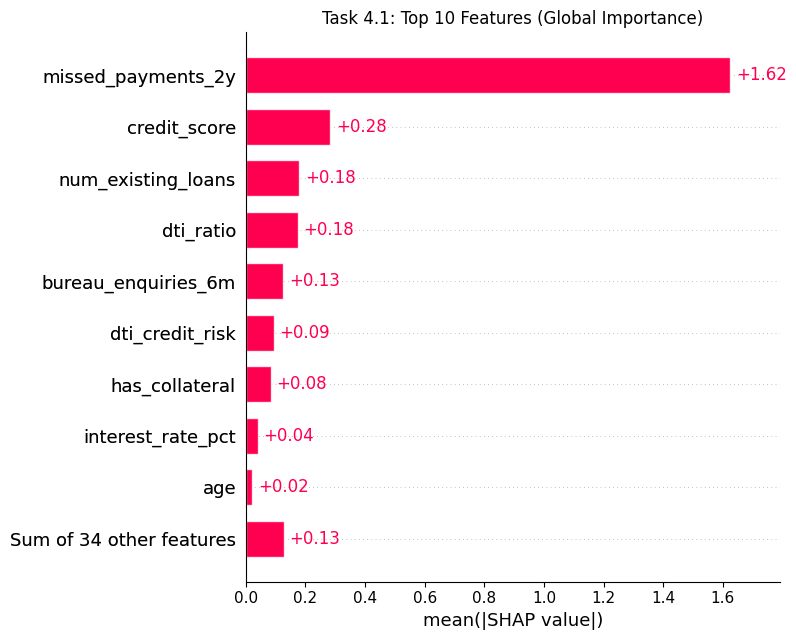

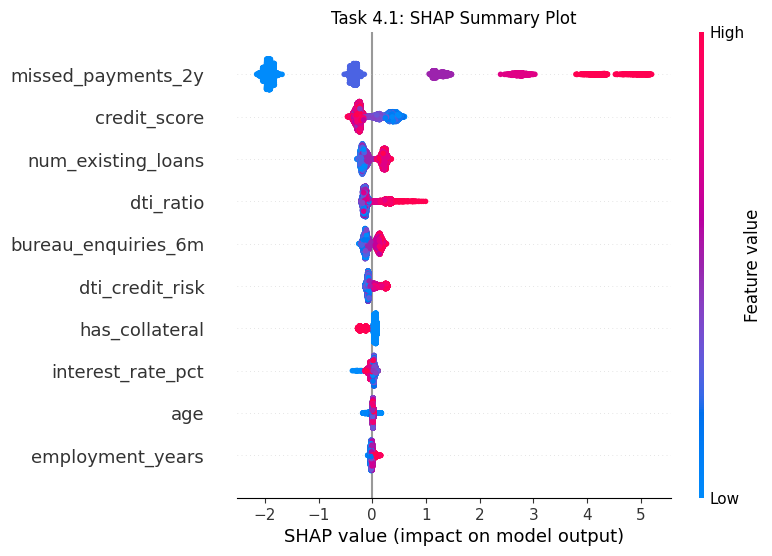

Generating Waterfall Plots...


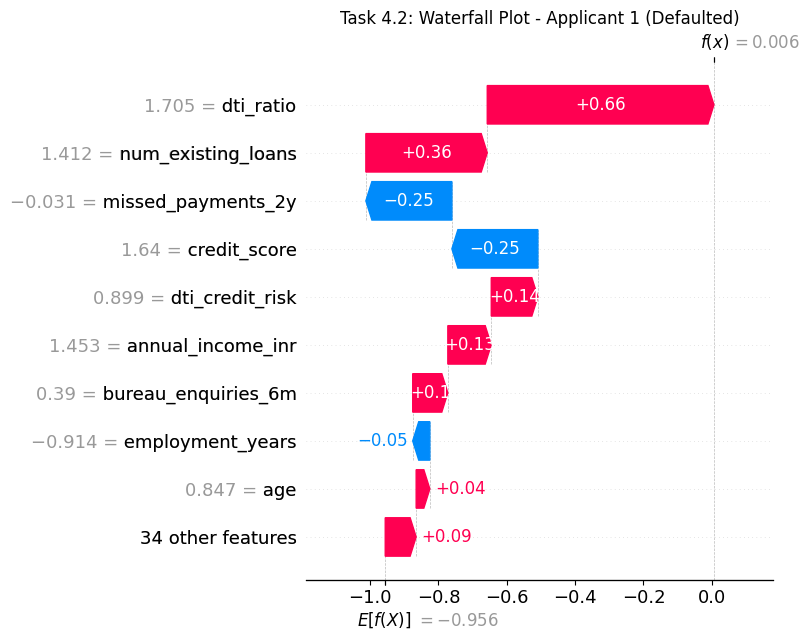

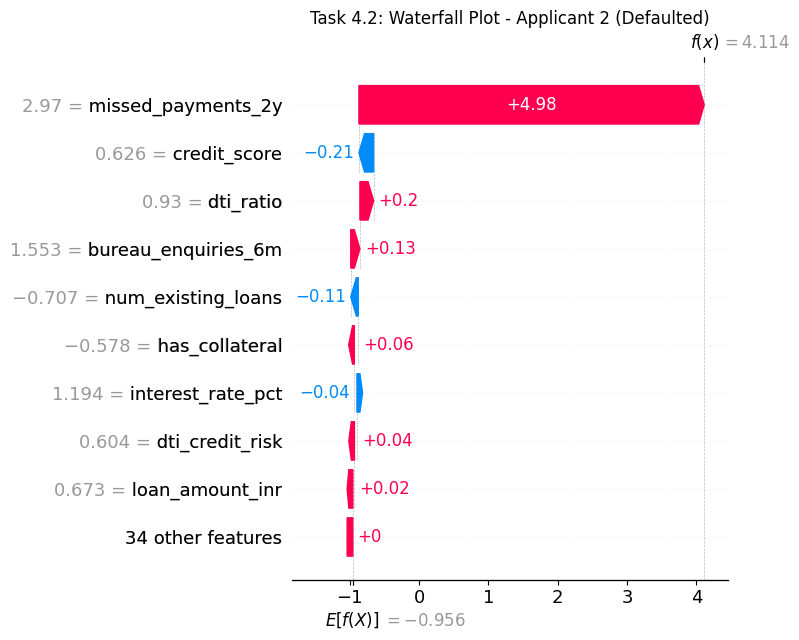

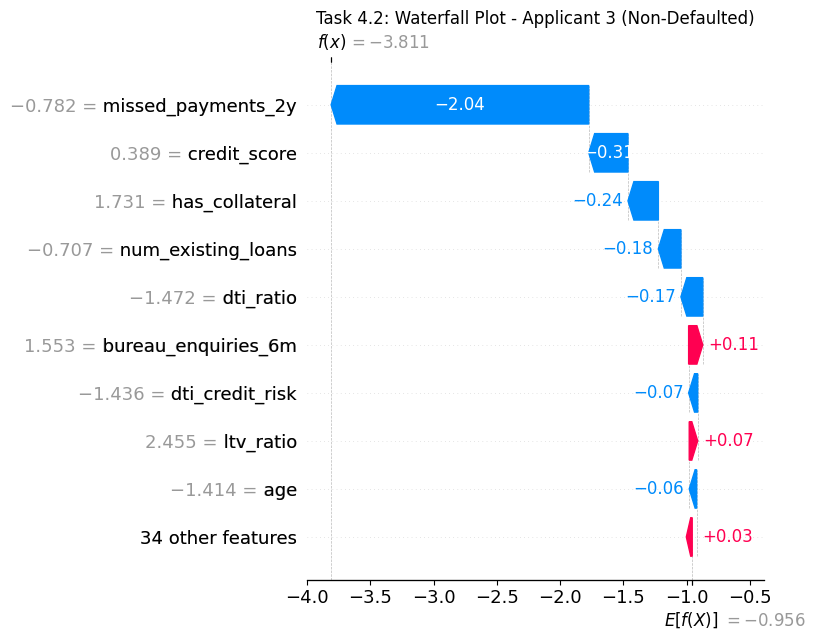

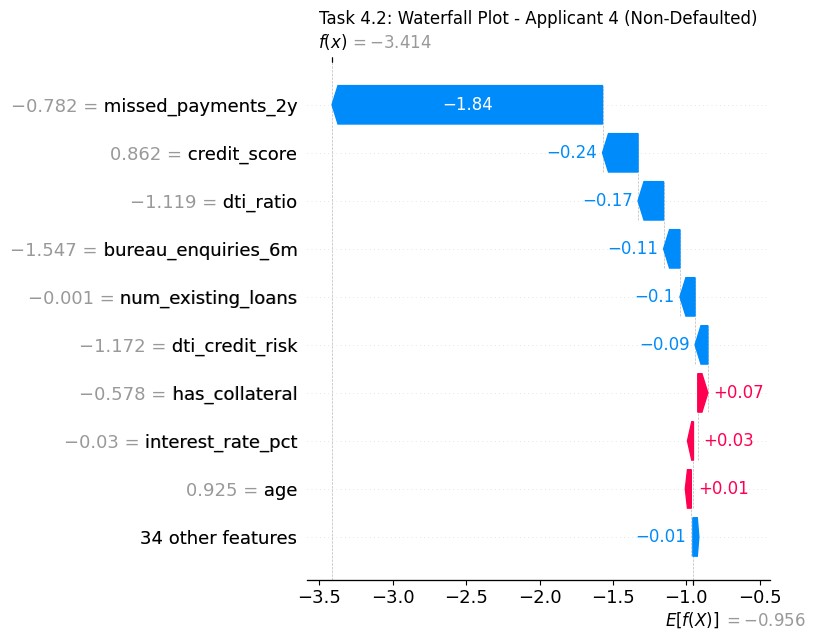

In [4]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize SHAP Explainer
# We use the XGBoost component from your trained StackingClassifier
xgb_model = final_model.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the full dataset
# (Using the encoded/scaled training data X_all)
shap_values = explainer(X_all)

# --- 4.1 Global Summary Plot & Bar Chart ---
print("Generating Global Summary Plots...")

# Bar Chart of Top 10 Features
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=10, show=False)
plt.title("Task 4.1: Top 10 Features (Global Importance)")
plt.tight_layout()
plt.show()

# Summary Dot Plot (showing impact direction)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_all, max_display=10, show=False)
plt.title("Task 4.1: SHAP Summary Plot")
plt.show()

# --- 4.2 Waterfall Plots for Specific Applicants ---
print("Generating Waterfall Plots...")

# Identify indices for 2 Defaulted and 2 Non-Defaulted applicants
defaulted_indices = y_all[y_all == 1].index[:2]
non_defaulted_indices = y_all[y_all == 0].index[:2]

# Map these back to the integer positions in the X_all matrix
all_indices = list(defaulted_indices) + list(non_defaulted_indices)
positions = [X_all.index.get_loc(idx) for idx in all_indices]

for i, pos in enumerate(positions):
    plt.figure(figsize=(10, 5))
    status = "Defaulted" if i < 2 else "Non-Defaulted"
    shap.plots.waterfall(shap_values[pos], show=False)
    plt.title(f"Task 4.2: Waterfall Plot - Applicant {i+1} ({status})")
    plt.tight_layout()
    plt.show()

In [7]:
# ==========================================
# 0. DEFINE MISSING VARIABLES
# ==========================================
# Ensure feature names match the exact order and content used during training
feature_names = X_all.columns.tolist()

# Define the optimal threshold (using 0.5 as default, adjust based on Task 3.4)
opt_threshold = 0.5

# ==========================================
# 1. CORRECTED PREPROCESSING FUNCTION
# ==========================================
def preprocess_for_inference(data, scaler, train_cols):
    df_p = data.copy()

    # Task 2.3: LTV Logic
    df_p['is_home_loan'] = df_p['ltv_ratio'].notnull().astype(int)
    df_p['ltv_ratio'] = df_p['ltv_ratio'].fillna(-1)

    # Task 2.1: Engineered Features (Same as Training)
    df_p['loan_to_income_ratio'] = df_p['loan_amount_inr'] / (df_p['annual_income_inr'] + 1)
    df_p['dti_credit_risk'] = df_p['dti_ratio'] / (df_p['credit_score'] / 700 + 1e-6)
    df_p['income_per_year_employed'] = df_p['annual_income_inr'] / (df_p['employment_years'] + 1)

    # Drop non-predictive columns
    loan_ids = df_p['loan_id']
    df_p = df_p.drop(columns=['loan_id', 'application_date', 'loan_purpose', 'default_flag'], errors='ignore')

    # Encoding & Alignment
    df_enc = pd.get_dummies(df_p, drop_first=True)

    # Ensure test columns match training columns (handles missing categories/order)
    df_enc = df_enc.reindex(columns=train_cols, fill_value=0)

    # --- FIX: Scale only the numerical columns the scaler was fit on ---
    # The scaler stores the names of the columns it saw in 'feature_names_in_'
    num_cols_to_scale = scaler.feature_names_in_
    df_enc[num_cols_to_scale] = scaler.transform(df_enc[num_cols_to_scale])

    return df_enc, loan_ids

# ==========================================
# 2. LOAD TEST DATA & PREDICT
# ==========================================
print("Loading test data and generating predictions...")
test_df = pd.read_csv('loan_test (1).csv')

# Preprocess test data
X_test_final, test_loan_ids = preprocess_for_inference(test_df, main_scaler, feature_names)

# Generate Probabilities using the final Stacking model
# We pass the full processed DataFrame (scaled numericals + dummies)
test_probs = final_model.predict_proba(X_test_final)[:, 1]

# Apply Threshold for final decision
test_predictions = (test_probs > opt_threshold).astype(int)

# ==========================================
# 3. EXPORT RESULTS
# ==========================================
output = pd.DataFrame({
    'loan_id': test_loan_ids,
    'default_probability': np.round(test_probs, 4),
    'risk_decision': test_predictions
})

# Add categorical labels for business clarity
output['risk_rating'] = pd.cut(output['default_probability'],
                               bins=[0, 0.2, 0.5, 0.8, 1.0],
                               labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'],
                               include_lowest=True)

# Save to CSV
output.to_csv('test_predictions_report.csv', index=False)

print("\n--- Inference Results Preview ---")
print(output.head())
print(f"\nSuccess: Predicted {len(output)} records.")
print(f"Decisions Summary: {output['risk_decision'].value_counts().to_dict()} (0=Approve, 1=Reject)")

Loading test data and generating predictions...

--- Inference Results Preview ---
     loan_id  default_probability  risk_decision  risk_rating
0  LN0009468               0.0704              0     Low Risk
1  LN0014847               0.0568              0     Low Risk
2  LN0011993               0.0735              0     Low Risk
3  LN0012068               0.1317              0     Low Risk
4  LN0001934               0.3712              0  Medium Risk

Success: Predicted 2500 records.
Decisions Summary: {0: 1960, 1: 540} (0=Approve, 1=Reject)
